In [ ]:
from exam_utils import *

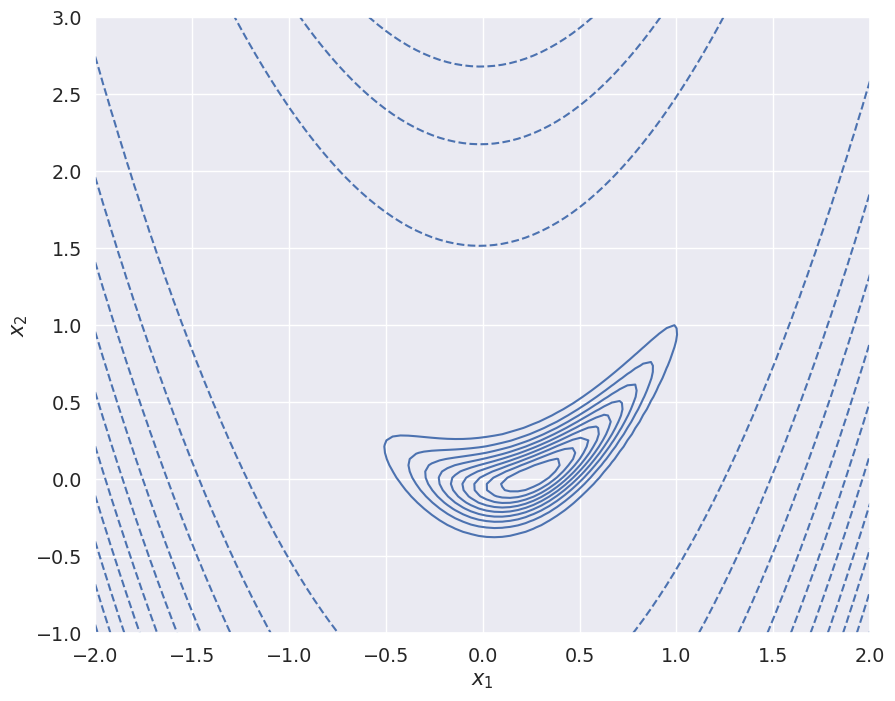

In [ ]:
# Part 5 Markov Chain Monte Carlo
C = 100
log_pos = lambda z1, z2 : -(1 - z1)**2 - 20*(z2 - z1**2)**2 -z1**2 - z2*2
fig, ax = plt.subplots(1, 1, figsize = (10,8))
z1star = jnp.linspace(-2, 2, 100)
z2star = jnp.linspace(-1, 3, 100)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: x)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: jnp.exp(x)) # Plot this not the log density


# grid = Grid2D(z1star, z2star, log_pos)
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# grid.plot_contours(ax, f=np.exp)
# ax.set(xlabel='$z_1$', ylabel='$z_2$', title='Contours of posterior density');

In [ ]:
# Q5.2
def log_pos_MCMC(theta):
    z1, z2 = theta[0], theta[1]
    return log_pos(z1, z2)

iterations = int(1e4)
theta_init = jnp.array([0, 1.5])
#theta_init = jnp.array([-5, 50])
thetas = metropolis(log_pos_MCMC, 2, 1, iterations, theta_init, seed = 1)
thetas = HMC(log_pos_MCMC, iterations, theta_init, seed = 1, step_size=0.01)


HMC done: accept_rate=0.085  t=6.0s


(8001, 2)


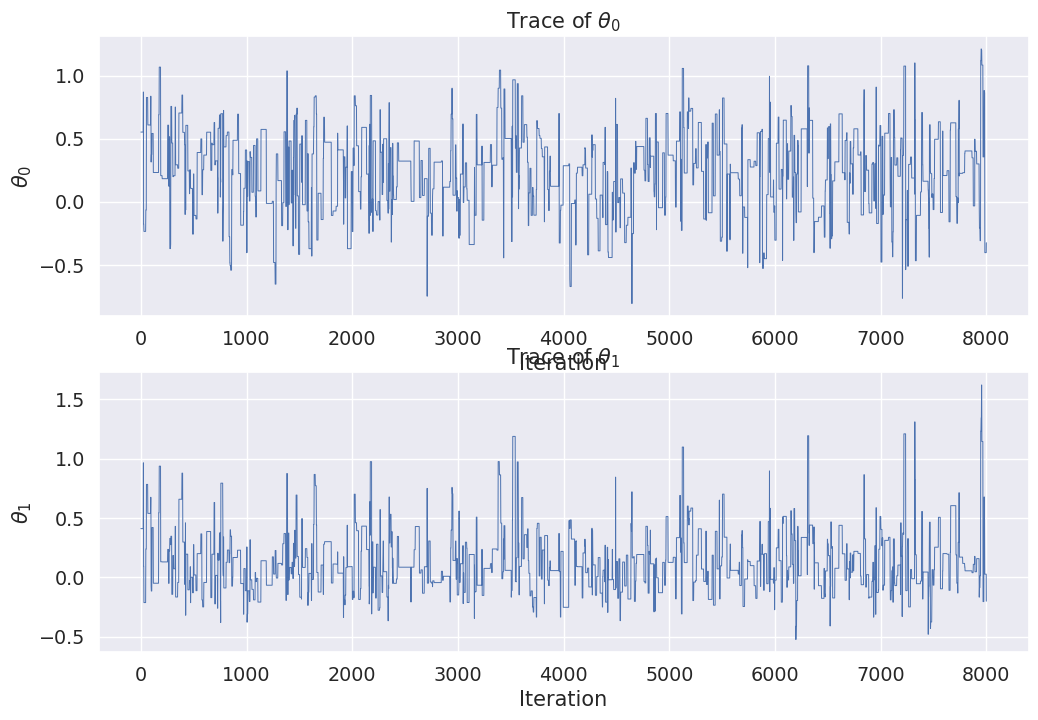

In [38]:
thetas = thetas[iterations//10:]
print(thetas.shape)
fig, ax = plt.subplots(2, 1, figsize = (12, 8))
plot_trace(ax, thetas)

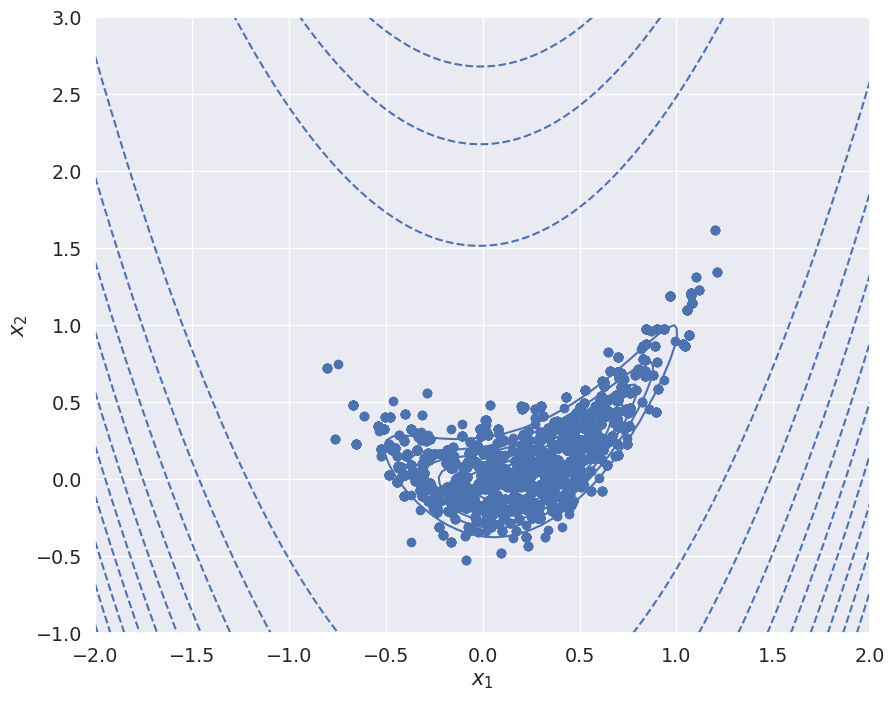

In [39]:
fig, ax = plt.subplots(1, 1, figsize = (10,8))
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: x)
plot_contour(ax, log_pos, z1star, z2star, transform= lambda x: jnp.exp(x)) # Plot this not the log density
ax.scatter(thetas[:,0], thetas[:,1])

In [40]:
z1, z2 = thetas[:, 0], thetas[:, 1]
mean_sin = np.mean(np.sin(z1*z2), 0)
print(f'E[sin(z1z2|D)] = {mean_sin:3.2f}')

E[sin(z1z2|D)] = 0.08


0.0770535158107403


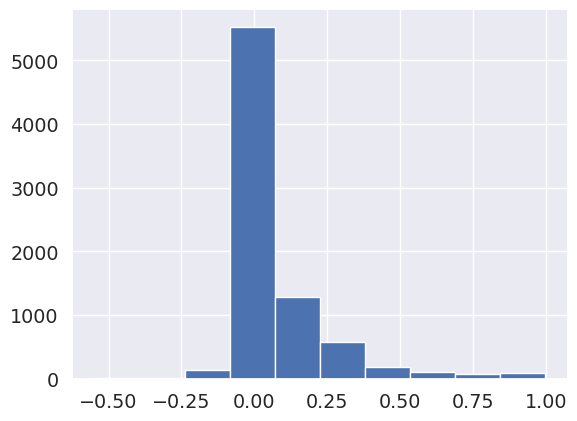

E[sin(z1z2|D)] = 0.08
0.7544057


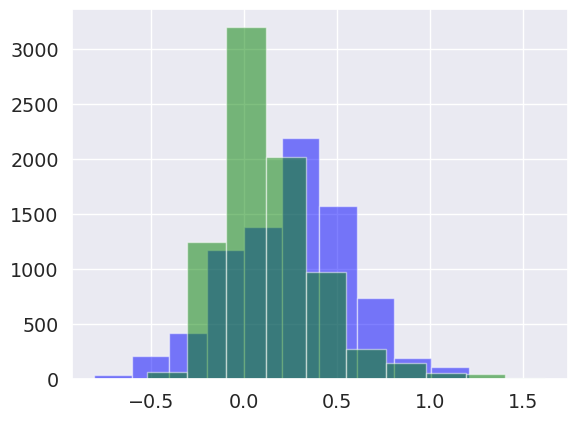

In [41]:
# Q5.3 With or without warmup? I would assume without but it is unclear. 
z1z2 = thetas[:,0] * thetas[:,1]
sin = jnp.sin(z1z2)
plt.hist(sin)
print(sin.mean())
plt.show()

z1, z2 = thetas[:, 0], thetas[:, 1]
mean_sin = np.mean(np.sin(z1*z2), 0)
print(f'E[sin(z1z2|D)] = {mean_sin:3.2f}')

plt.hist(thetas[:,0], color="blue", alpha=0.5)
plt.hist(thetas[:,1], color="green", alpha=0.5)

print((thetas[:,0] > thetas[:,1]).mean())


Acceptance ratio: 0.08
E[sin(z1z2|D)] = 0.08


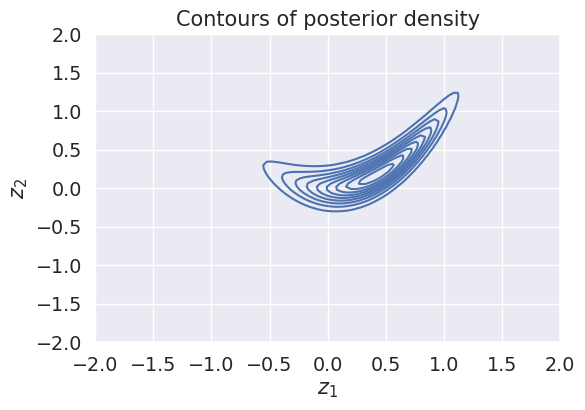

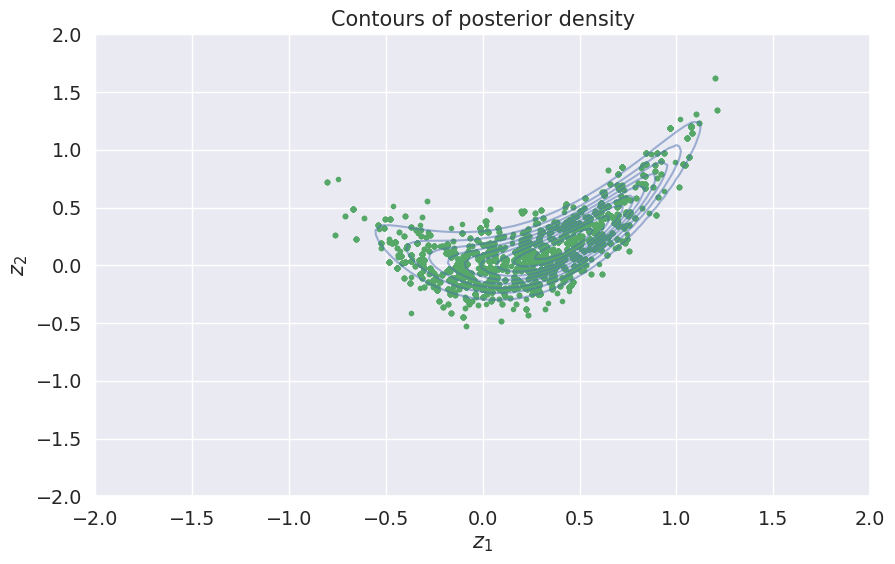

In [42]:
# Solution code. Very strange
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

z1s = np.linspace(-2, 2, 101)
z2s = np.linspace(-2, 2, 100)
log_target = lambda z1, z2: -(1-z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2
grid = Grid2D(z1s, z2s, log_target)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
grid.plot_contours(ax, f=np.exp)
ax.set(xlabel='$z_1$', ylabel='$z_2$', title='Contours of posterior density');


thetas = metropolis(log_pos_MCMC,
                    num_params=2,
                    tau=1,
                    num_iter=10000,
                    seed=1,
                    theta_init=jnp.array([0, 1.5]))
# discard warm-up
thetas = thetas[1000:, :]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(thetas[:, 0], thetas[:, 1], 'g.')
grid.plot_contours(ax, f=np.exp, alpha=0.5)
ax.set(xlabel='$z_1$', ylabel='$z_2$', title='Contours of posterior density');

z1, z2 = thetas[:, 0], thetas[:, 1]
mean_sin = np.mean(np.sin(z1*z2), 0)
print(f'E[sin(z1z2|D)] = {mean_sin:3.2f}')